In [1]:
import pandas as pd

# Path to your CSV file
csv_path = "/kaggle/input/datasets/seifabdelbaky/accidents-with-weather/accidents_with_weather.csv"

# Read CSV into DataFrame
df = pd.read_csv(csv_path, low_memory=False)

# Optional: see the first few rows
print(df.head())

# Optional: check DataFrame shape and columns
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

  collision_index  collision_year collision_ref_no  location_easting_osgr  \
0   2025010551784            2025        010551784               528234.0   
1   2025010551786            2025        010551786               529585.0   
2   2025010551792            2025        010551792               524767.0   
3   2025010551794            2025        010551794               527549.0   
4   2025010551795            2025        010551795               534910.0   

   location_northing_osgr  longitude  latitude  police_force  \
0                185607.0   -0.15174  51.55478             1   
1                178570.0   -0.13485  51.49124             1   
2                187961.0   -0.20089  51.57671             1   
3                184185.0   -0.16213  51.54216             1   
4                183108.0   -0.05647  51.53077             1   

   collision_severity  number_of_vehicles  ...  wx_snow_depth wx_weather_code  \
0                   3                   3  ...            0.0          

In [2]:
# First Dimension : Acccuracy

# The target variable is categorical [1: Fatal, 2: Serious, 3:Slight]
assert (df['collision_severity'] <1).sum()==0 , "Collision Severity ranges between 1 and 3"
assert (df['collision_severity'] >3).sum()==0 , "Collision Severity ranges between 1 and 3"

# Longitude and latitude values must range inside England's borders
assert (df['latitude']<49.9).sum()==0 , "This is out of England"
assert (df['latitude']>61).sum()==0 , "This is out of England" 
assert (df['longitude']<-8).sum()==0 , "This is out of England" 
assert (df['longitude']>2).sum()==0 , "This is out of England" 

# Temperature in Celsius wasn't recorded ever to be less than -70 or more than 90
assert (df['wx_temperature_2m'] < -70).sum()==0, "Temperature can't be less than -70"
assert (df['wx_temperature_2m'] > 90).sum()==0, "Temperature can't be more than 90"

# Humidity is a percentage
assert ((df['wx_relative_humidity_2m'])<0).sum()==0, "Humidity can't be negative"
assert ((df['wx_relative_humidity_2m'])>100).sum()==0, "Humidity can't exceed 100"
# day of week between 1 and 7
assert (df['day_of_week'] <1).sum()==0 , "Invalid day"
assert (df['day_of_week'] >7).sum()==0 , "Invalid day"


In [3]:
# Second Dimension: Completeness
# Count number of NaNs in each column
null_counts = df.isnull().sum()
# print(null_counts)
# print((df['speed_limit']==-1).sum())

print (df['collision_severity'].isnull().sum()) # 0 missing


0


In [4]:
print (df['latitude'].isnull().sum()) # 1 is missing
print (df['longitude'].isnull().sum()) # 1 is missing


1
1


In [5]:
print (df['date'].isnull().sum()) # 0 is missing
print (df['time'].isnull().sum()) # 0 is missing
print (df['day_of_week'].isnull().sum()) # 0 is missing


0
0
0


In [6]:
print (df['road_type'].isnull().sum()) # 0 null
print ((df['road_type']==-1).sum()) # 0 data missing
print ((df['road_type']==9).sum()) # 1124 unknown 
# total for road_type = 1124 nulls


0
0
1124


In [7]:
print (df['speed_limit'].isnull().sum()) # 0
print ((df['speed_limit']==-1).sum()) # 185 data missing
print ((df['speed_limit']==99).sum()) # 0 unknown
#total for speed_limit = 185


0
185
0


In [8]:
print (df['junction_detail'].isnull().sum()) # 0
print ((df['junction_detail']==-1).sum()) # 5410 data missing
print ((df['junction_detail']==99).sum()) # 12 unknown
#total for junction_detail = 5422

0
5410
12


In [9]:
print (df['junction_control'].isnull().sum()) # 0
print ((df['junction_control']==-1).sum()) # 21093 data missing
print ((df['junction_control']==9).sum()) # 1454 unknown
#total for junction_control = 22547

0
21093
1454


In [10]:
print (df['second_road_class'].isnull().sum()) # 0
print ((df['second_road_class']==-1).sum()) # 6215 data missing
print ((df['second_road_class']==9).sum()) # 34 unknown
#total for second_road_class = 6249

0
6215
34


In [11]:
print (df['pedestrian_crossing'].isnull().sum()) # 0
print ((df['pedestrian_crossing']==-1).sum()) # 928 data missing
print ((df['pedestrian_crossing']==99).sum()) # 1631 unknown
#total for pedestrian_crossing = 2559

0
928
1631


In [12]:
print (df['special_conditions_at_site'].isnull().sum()) # 0
print ((df['special_conditions_at_site']==-1).sum()) # 31898 data missing
print ((df['special_conditions_at_site']==9).sum()) # 1425 unknown
#total for special_conditions_at_site = 33323

0
31898
1425


In [13]:
print (df['carriageway_hazards'].isnull().sum()) # 0
print ((df['carriageway_hazards']==-1).sum()) # 918 data missing
print ((df['carriageway_hazards']==99).sum()) # 1502 unknown
#total for carriageway_hazards = 2420

0
918
1502


In [14]:
print (df['light_conditions'].isnull().sum()) # 0
print ((df['light_conditions']==-1).sum()) # 307 data missing

#total for light_conditions = 307

0
307


In [15]:
print (df['weather_conditions'].isnull().sum()) # 0
print ((df['weather_conditions']==-1).sum()) # 422 data missing
print ((df['weather_conditions']==9).sum()) # 1163 unknown
#total for weather_conditions = 1585

0
422
1163


In [16]:
print (df['road_surface_conditions'].isnull().sum()) # 0
print ((df['road_surface_conditions']==-1).sum()) # 922 data missing
print ((df['road_surface_conditions']==9).sum()) # 623 unknown
#total for road_surface_conditions = 1545

0
922
623


In [17]:
print (df['urban_or_rural_area'].isnull().sum()) # 0
print ((df['urban_or_rural_area']==-1).sum()) # 0 data missing

#total for light_conditions = 0

0
0


In [18]:
print (df['number_of_vehicles'].isnull().sum()) # 0
print (df['number_of_casualties'].isnull().sum()) # 0

#total for number_of_vehicles = 0

0
0


In [19]:
print (df['did_police_officer_attend_scene_of_accident'].isnull().sum()) # 0
print ((df['did_police_officer_attend_scene_of_accident']==-1).sum()) # 609 data missing

#total for light_conditions = 609

0
609


In [20]:
# print (df['wx_temperature_2m'].isnull().sum())
# print (df['wx_relative_humidity_2m'].isnull().sum())
# print (df['wx_precipitation'].isnull().sum())
# print (df['wx_rain'].isnull().sum())
# print (df['wx_snowfall'].isnull().sum())
print (df['wx_snow_depth'].isnull().sum()) # 144 wel ba2y kolo 133
# print (df['wx_wind_speed_10m'].isnull().sum())
# print (df['wx_wind_gusts_10m'].isnull().sum())
# print (df['wx_surface_pressure'].isnull().sum())
# print (df['wx_weather_code'].isnull().sum())

144


In [21]:
duplicates = df[df['collision_index'].duplicated()]
print(duplicates)

Empty DataFrame
Columns: [collision_index, collision_year, collision_ref_no, location_easting_osgr, location_northing_osgr, longitude, latitude, police_force, collision_severity, number_of_vehicles, number_of_casualties, date, day_of_week, time, local_authority_district, local_authority_ons_district, local_authority_highway, local_authority_highway_current, first_road_class, first_road_number, road_type, speed_limit, junction_detail_historic, junction_detail, junction_control, second_road_class, second_road_number, pedestrian_crossing_human_control_historic, pedestrian_crossing_physical_facilities_historic, pedestrian_crossing, light_conditions, weather_conditions, road_surface_conditions, special_conditions_at_site, carriageway_hazards_historic, carriageway_hazards, urban_or_rural_area, did_police_officer_attend_scene_of_accident, trunk_road_flag, lsoa_of_accident_location, enhanced_severity_collision, collision_injury_based, collision_adjusted_severity_serious, collision_adjusted_sev

In [22]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)

Index(['collision_year', 'location_easting_osgr', 'location_northing_osgr',
       'longitude', 'latitude', 'police_force', 'collision_severity',
       'number_of_vehicles', 'number_of_casualties', 'day_of_week',
       'local_authority_district', 'first_road_class', 'first_road_number',
       'road_type', 'speed_limit', 'junction_detail_historic',
       'junction_detail', 'junction_control', 'second_road_class',
       'second_road_number', 'pedestrian_crossing_human_control_historic',
       'pedestrian_crossing_physical_facilities_historic',
       'pedestrian_crossing', 'light_conditions', 'weather_conditions',
       'road_surface_conditions', 'special_conditions_at_site',
       'carriageway_hazards_historic', 'carriageway_hazards',
       'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident',
       'trunk_road_flag', 'enhanced_severity_collision',
       'collision_injury_based', 'collision_adjusted_severity_serious',
       'collision_adjusted_severity_slight

In [23]:
print(df[numerical_cols].describe())

       collision_year  location_easting_osgr  location_northing_osgr  \
count         48472.0           48471.000000            4.847100e+04   
mean           2025.0          456275.211962            2.755787e+05   
std               0.0           92138.408435            1.433069e+05   
min            2025.0           75011.000000            1.029100e+04   
25%            2025.0          395146.500000            1.757505e+05   
50%            2025.0          460820.000000            2.228320e+05   
75%            2025.0          529811.500000            3.814140e+05   
max            2025.0          655126.000000            1.144900e+06   

          longitude      latitude  police_force  collision_severity  \
count  48471.000000  48471.000000  48472.000000        48472.000000   
mean      -1.190995     52.367636     27.489107            2.724459   
std        1.346922      1.291382     23.777287            0.477850   
min       -7.440790     49.913030      1.000000            1.000000

In [24]:
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Boolean DataFrame: True if the value is an outlier
outliers = (df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))

# Count outliers per column
outlier_counts = outliers.sum()
print(outlier_counts)

collision_year                                          0
location_easting_osgr                                 286
location_northing_osgr                                510
longitude                                             299
latitude                                              499
police_force                                            0
collision_severity                                      0
number_of_vehicles                                    942
number_of_casualties                                 8686
day_of_week                                             0
local_authority_district                                0
first_road_class                                        0
first_road_number                                    7461
road_type                                           13077
speed_limit                                          8653
junction_detail_historic                             8561
junction_detail                                        12
junction_contr

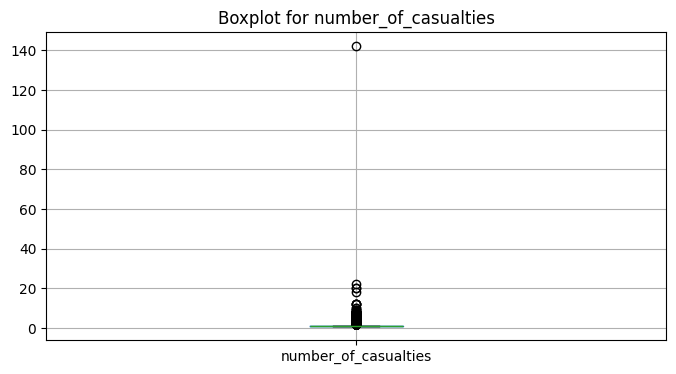

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
df.boxplot(column='number_of_casualties')
plt.title('Boxplot for number_of_casualties')
plt.show()

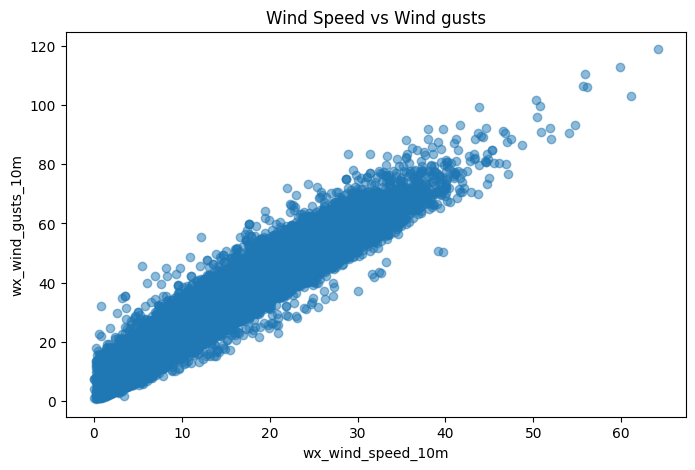

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['wx_wind_speed_10m'], df['wx_wind_gusts_10m'], alpha=0.5)
plt.xlabel('wx_wind_speed_10m')
plt.ylabel('wx_wind_gusts_10m')
plt.title('Wind Speed vs Wind gusts')
plt.show()

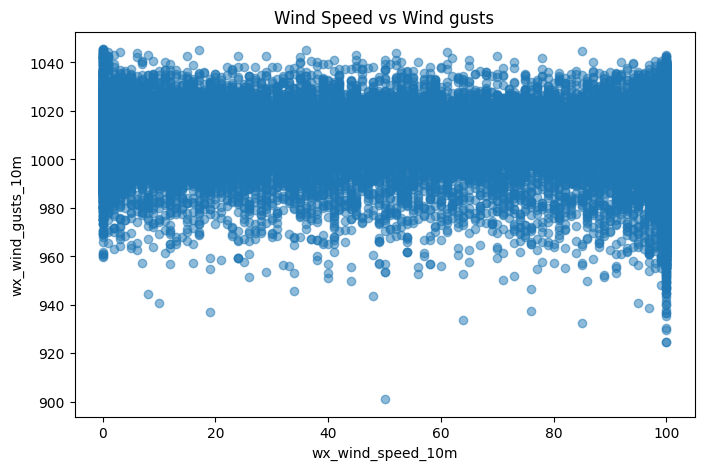

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['wx_cloud_cover'], df['wx_surface_pressure'], alpha=0.5)
plt.xlabel('wx_wind_speed_10m')
plt.ylabel('wx_wind_gusts_10m')
plt.title('Wind Speed vs Wind gusts')
plt.show()

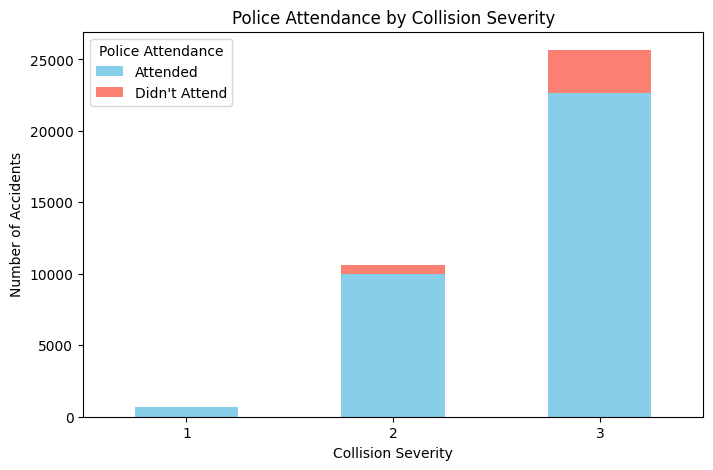

In [28]:
import matplotlib.pyplot as plt

# Keep only 1 (attended) and 2 (didn't attend)
df_filtered = df[df['did_police_officer_attend_scene_of_accident'].isin([1, 2])]

# Group by severity and police attendance, then count the number of accidents
grouped = df_filtered.groupby(['collision_severity', 'did_police_officer_attend_scene_of_accident']).size().unstack()

# Map attendance numbers to labels
grouped = grouped.rename(columns={1: 'Attended', 2: "Didn't Attend"})

# Plot a stacked bar chart
grouped.plot(kind='bar', stacked=True, figsize=(8,5), color=['skyblue', 'salmon'])
plt.ylabel('Number of Accidents')
plt.xlabel('Collision Severity')
plt.title('Police Attendance by Collision Severity')
plt.xticks(rotation=0)
plt.legend(title='Police Attendance')
plt.show()

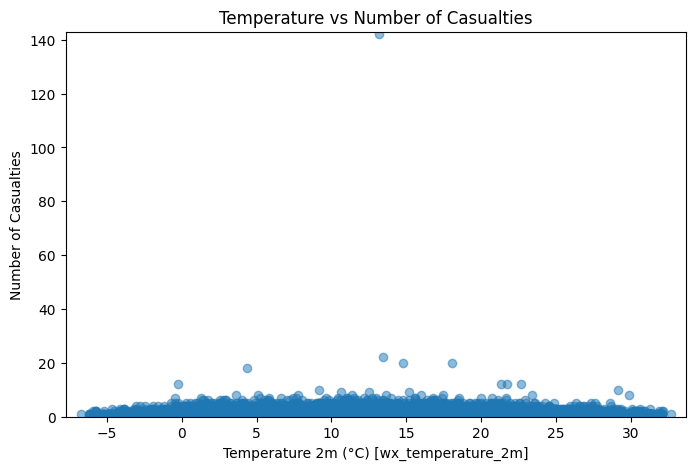

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['wx_temperature_2m'], df['number_of_casualties'], alpha=0.5)

# Set axis labels
plt.xlabel('Temperature 2m (°C) [wx_temperature_2m]')
plt.ylabel('Number of Casualties')

# Set axis limits (adjust as needed)
plt.xlim(df['wx_temperature_2m'].min()-1, df['wx_temperature_2m'].max()+1)  # x-axis
plt.ylim(0, df['number_of_casualties'].max()+1)  # y-axis

plt.title('Temperature vs Number of Casualties')
plt.show()

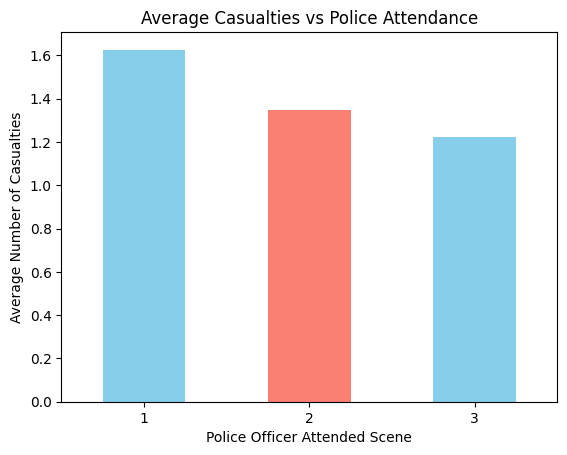

In [30]:
import matplotlib.pyplot as plt

# Group by police attendance and calculate mean casualties
grouped = df.groupby('collision_severity')['number_of_casualties'].mean()

# Plot
grouped.plot(kind='bar', color=['skyblue', 'salmon'])
plt.ylabel('Average Number of Casualties')
plt.xlabel('Police Officer Attended Scene')
plt.title('Average Casualties vs Police Attendance')
plt.xticks(rotation=0)
plt.show()

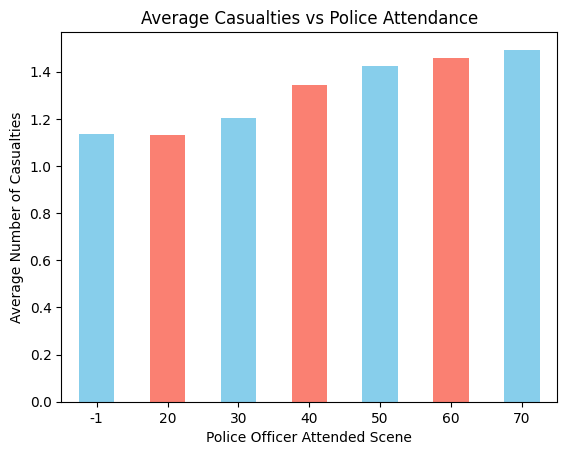

In [31]:
import matplotlib.pyplot as plt

# Group by police attendance and calculate mean casualties
grouped = df.groupby('speed_limit')['number_of_casualties'].mean()

# Plot
grouped.plot(kind='bar', color=['skyblue', 'salmon'])
plt.ylabel('Average Number of Casualties')
plt.xlabel('Police Officer Attended Scene')
plt.title('Average Casualties vs Police Attendance')
plt.xticks(rotation=0)
plt.show()

In [32]:
# Consistency
invalid = df[(df['collision_severity'] == 1) & (df['number_of_casualties'] == 0)]
print(invalid)
invalid_rain = df[(df['wx_rain'] > 0) & (df['wx_precipitation'] == 0)]
print(invalid)
suspicious = df[
    (df['collision_severity'] == 1) &
    (df['did_police_officer_attend_scene_of_accident'] == 2)
]
print(suspicious)
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
invalid_year = df[df['date'].dt.year != df['collision_year']]
print(invalid_year)

Empty DataFrame
Columns: [collision_index, collision_year, collision_ref_no, location_easting_osgr, location_northing_osgr, longitude, latitude, police_force, collision_severity, number_of_vehicles, number_of_casualties, date, day_of_week, time, local_authority_district, local_authority_ons_district, local_authority_highway, local_authority_highway_current, first_road_class, first_road_number, road_type, speed_limit, junction_detail_historic, junction_detail, junction_control, second_road_class, second_road_number, pedestrian_crossing_human_control_historic, pedestrian_crossing_physical_facilities_historic, pedestrian_crossing, light_conditions, weather_conditions, road_surface_conditions, special_conditions_at_site, carriageway_hazards_historic, carriageway_hazards, urban_or_rural_area, did_police_officer_attend_scene_of_accident, trunk_road_flag, lsoa_of_accident_location, enhanced_severity_collision, collision_injury_based, collision_adjusted_severity_serious, collision_adjusted_sev